importing libraries

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


loading files

In [12]:
# load the files
tickets = pd.read_csv("gold_match_tickets.csv")
context = pd.read_csv("gold_match_context.csv")


cleaning columns 

In [13]:
# clean column names
tickets.columns = tickets.columns.str.strip()
context.columns = context.columns.str.strip()

selecting columns

In [14]:
# keep needed columns
tickets = tickets[[
    "match_id",
    "tickets_sold_total",
    "seasonpass_holders",
    "tickets_sold_b2c",
    "tickets_sold_b2b"
]]

context = context[[
    "match_id",
    "promo_tickets_total",
    "pct_free_tickets",
    "has_promotion",
    "promotion_names"
]]

merging tables

In [15]:
# merge datasets
df = pd.merge(tickets, context, on="match_id")

# convert promotion to numbers
df["has_promotion"] = df["has_promotion"].astype(str).str.lower()
df["has_promotion"] = df["has_promotion"].replace({
    "true":1,
    "false":0,
    "yes":1,
    "no":0
})

df["has_promotion"] = df["has_promotion"].fillna(0)

/var/folders/yz/b26n718j6db76871t423v1jm0000gn/T/ipykernel_26080/3460974410.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["has_promotion"] = df["has_promotion"].replace({


displaying data

In [16]:
print("Merged Dataset")
display(df.head())

Merged Dataset


,match_id,tickets_sold_total,seasonpass_holders,tickets_sold_b2c,tickets_sold_b2b,promo_tickets_total,pct_free_tickets,has_promotion,promotion_names
0,3kewmr690bhoid47mku9wfgno,5988,4405,1095,882,0,31.3,0,NaN
1,3nrkjdhpc5zse1sdzt1onor2s,6652,4405,1807,953,0,21.9,0,NaN
2,3rwouz4640n6ngfbwrwsqkp3o,7385,4405,2793,880,809,32.0,1,1+1 actie
3,3vk3btgbt7w7qy9hjp3f2934k,6929,4405,1981,1003,0,26.0,0,NaN
4,3yp7glzujzj8nc07qp0sd0kr8,6901,4405,1936,925,0,23.2,0,NaN


summary

In [20]:
# quick summary
print(df.describe())
summary_stats = df.describe()

print("Summary Statistics")
display(summary_stats)

       tickets_sold_total  seasonpass_holders  tickets_sold_b2c  \
count           71.000000           71.000000         71.000000   
mean          6787.563380         4321.887324       1862.169014   
std           1072.794718          195.556535       1021.920223   
min           4688.000000         4032.000000          0.000000   
25%           5903.000000         4235.000000       1063.000000   
50%           6979.000000         4405.000000       2111.000000   
75%           7596.000000         4546.000000       2675.500000   
max           8682.000000         4546.000000       3823.000000   

       tickets_sold_b2b  promo_tickets_total  pct_free_tickets  has_promotion  
count         71.000000            71.000000         71.000000      71.000000  
mean        1198.295775            80.140845         29.035211       0.366197  
std          386.203551           191.427965         15.777263       0.485193  
min          758.000000             0.000000          0.000000       0.00000

,tickets_sold_total,seasonpass_holders,tickets_sold_b2c,tickets_sold_b2b,promo_tickets_total,pct_free_tickets,has_promotion
count,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000
mean,6787.563380,4321.887324,1862.169014,1198.295775,80.140845,29.035211,0.366197
std,1072.794718,195.556535,1021.920223,386.203551,191.427965,15.777263,0.485193
min,4688.000000,4032.000000,0.000000,758.000000,0.000000,0.000000,0.000000
25%,5903.000000,4235.000000,1063.000000,920.000000,0.000000,22.350000,0.000000
50%,6979.000000,4405.000000,2111.000000,1083.000000,0.000000,28.900000,0.000000
75%,7596.000000,4546.000000,2675.500000,1430.000000,12.000000,38.250000,1.000000
max,8682.000000,4546.000000,3823.000000,2823.000000,809.000000,68.700000,1.000000


generating a heatmap

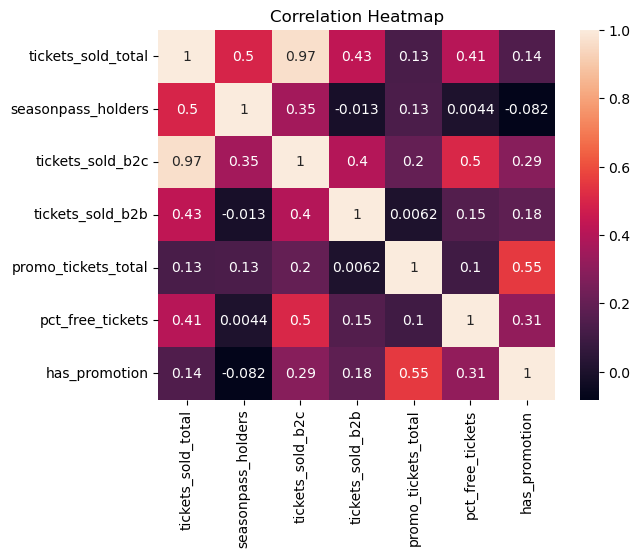

In [18]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")

plt.show()

generating bar graph

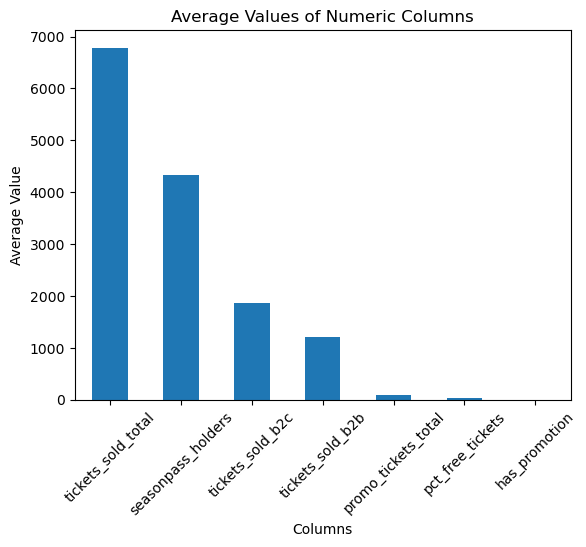

In [19]:
# select numeric columns
numeric_cols = df.select_dtypes(include="number")

# calculate averages
avg_values = numeric_cols.mean()

# bar chart
avg_values.plot(kind="bar")

plt.xlabel("Columns")
plt.ylabel("Average Value")
plt.title("Average Values of Numeric Columns")

plt.xticks(rotation=45)

plt.show()